In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import chi2, multivariate_normal
from tqdm.notebook import tqdm
sns.set()
#sns.set_style('dark')

In [2]:
from numba import jit

@jit(nopython=True)
def amoc_gen(alarms, first_detect_time, last_detect_time, max_time_detection):
    """
    Generate an AMOC curve.
    Arguments: 
        alarms: p-vals?
        first_detect_time
        max_time_detection: the maximum number of days to detect a fire (int)
    Returns: 
        FPR_array: false positive rates (list)
        detection_array: days to detection time (list)
    """
    thresholds = np.arange(0, 1, .001)
    FPR_array = []
    detection_array = []

    # Check FPR and days to detection for each probability threshold
    for threshold in thresholds:
        detected = False
        detection_time = 0
        false_positives = 0
        true_negatives = 0
        
        for p_value in alarms:
            
            # Two cases: false postive and true positive
            if p_value <= threshold:
                if detection_time < first_detect_time or detection_time > last_detect_time: # Check for false positive
                    false_positives += 1
                
                else: # True positive: fire detected
                    detected = True
                    detection_array.append(detection_time - first_detect_time)
                    break
            
            else: # Two cases: false negative and true negative
                if detection_time < first_detect_time: # Check for true negative -- needed for FPR
                    true_negatives += 1
            detection_time += 1

        if false_positives + true_negatives != 0:
            fp_rate = (false_positives) / (false_positives + true_negatives)
            
        else:
            fp_rate = 0
            pass

        FPR_array.append(fp_rate)
        if not detected:
            detection_array.append(max_time_detection)
    
    return FPR_array, detection_array

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [3]:
@jit(nopython=True)
def average_AMOC(AMOC_points):
    """
    Generate an average AMOC curve.
    Arguments: 
        alarms_dataset: List of lists of tuples, where points are FPRs and associated
                        detection times
                        [ [(FPR, detection time), (FPR, detection time)], ...] 
                          [(FPR, detection time), (FPR, detection time)], ...] 
                          ...
                        ]
    Returns: 
        mean_days_per_threshold: list of mean days to detection for each threshold
    """
    mean_days_per_threshold = []
    thresholds = np.arange(0, 1, .001)
    
    # Find mean detection time for each threshold
    for k in range(len(thresholds)):
        threshold = thresholds[k]
        summed_days = 0
        
        # Approximate detection time for threshold using closest FPR in each simulation
        for i in range(0, len(AMOC_points)):
            current_dataset = AMOC_points[i]  # Get list of alarm values
            closest_pair = current_dataset[0] # Find pair with closest probability threshold
            
            for j in range(0, len(current_dataset)):
                curr_point = current_dataset[j]     # point: (FPR, days to detection)
                if np.abs(curr_point[0] - threshold) < np.abs(closest_pair[0] - threshold):
                    closest_pair = curr_point
            
            # sum the detection times of each dataset that correspond with 
            # probability threshold
            summed_days += closest_pair[1]
        
        mean_days = summed_days / len(AMOC_points)
        mean_days_per_threshold.append(mean_days)
    
    return mean_days_per_threshold, thresholds

In [4]:
sim_results_path = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results/'
sim_results_path_cai = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results_cai/'

In [5]:
# mult_coeff is only for dim=50
simulation_prefixes = ['cai_model_one', 'cai_model_three', 
                       'orthogonal', 'cholesky']
# no change only goes up to dim=30
no_change_prefixes = ['cai_model_one_no_change', 'cai_model_three_no_change', 
                       'orthogonal_no_change', 'cholesky_no_change']
# handle dim=50 separately?
simulation_dims = ['_6', '_10', '_15', '_20', '_30', '_50']
# random seeds
random_seeds = np.arange(50, 75)
# first possible detection time
first_possible_detect_time = 401
last_possible_detect_time = 600

In [6]:
def amoc_lrt_vals(lrt_vals):
    # input should be padded vals
    p_vals = np.array([chi2.pdf(lrt_vals[:, i], 2) for i in range(lrt_vals.shape[1])]).T
    p_vals_corrected = apply_fdr_correction(p_vals)
    fprs = []
    detections = []
    for i in range(p_vals_corrected.shape[1]):
        fpr_array, detection_array = amoc_gen(p_vals_corrected[:, i], 
                                              first_detect_time=first_possible_detect_time, 
                                              last_detect_time=last_possible_detect_time, 
                                              max_time_detection=last_possible_detect_time-first_possible_detect_time)
        fprs.append(fpr_array)
        detections.append(detection_array)
    fprs = np.array(fprs)
    detections = np.array(detections)
    fpr_result = fprs.max(axis=0)
    detect_result = detections.min(axis=0)
    
    return fpr_result, detect_result
    
def symmetrize_from_vector(a, dim):
    """
    Turns a vector of lower triangular matrix entries into symmetric matrix
    """
    A = np.zeros((dim,dim))
    A[np.tril_indices(A.shape[0], k = 0)] = a
    A = A + A.T - np.diag(np.diag(A))

    return A

def get_h_matrices(full_path, num_mats, dim):
    H_s = []
    for i in range(num_mats):
        H_i = np.loadtxt(os.path.join(full_path, 'matrix_{}.csv'.format(i)))
        H_s.append(symmetrize_from_vector(H_i, dim))
    return np.array(H_s)

In [7]:
all_sims_names = []
all_fprs = []
all_detects = []
all_amoc_means = []
all_amoc_thresholds = []
for sim in simulation_prefixes:
    for dim in simulation_dims:
        print(sim, dim)
        curr_fprs = []
        curr_detects = []
        fpr_detect_pairs = []
        for seed in random_seeds:
            full_path = os.path.join(sim_results_path, sim+dim+"/"+str(seed))
            lrt_vals = np.loadtxt(os.path.join(full_path, 'lrt_vals.csv'), delimiter=',')
            lrt_vals_padded = np.pad(lrt_vals, [(100, 100), (0,0)], mode='constant')
            changed_indices = np.loadtxt(os.path.join(full_path, 'changed_indx.csv')).astype(int)
            H_s = get_h_matrices(full_path, num_mats=lrt_vals_padded.shape[1], dim=int(dim[1:]))
            fpr_result, detect_result = amoc_lrt_vals(lrt_vals_padded)
            curr_fprs.append(fpr_result)
            curr_detects.append(detect_result)
            merged_list = [(fpr_result[i], detect_result[i]) for i in range(0, len(fpr_result))]
            fpr_detect_pairs.append(merged_list)
        all_fprs.append(curr_fprs)
        all_detects.append(curr_detects)
        means_per_threshold, thresholds = average_AMOC(np.array(fpr_detect_pairs))
        all_amoc_means.append(list(means_per_threshold))
        all_amoc_thresholds.append(thresholds)
        all_sims_names.append(sim+dim)
#         plt.plot(thresholds, means_per_threshold, '.b-')
#         plt.xlabel('Threshold')
#         plt.ylabel('Detection Time')
#         plt.title('Average AMOC Curve for {} at dim {}'.format(sim, dim))
all_amoc_means = np.array(all_amoc_means)
all_amoc_thresholds = np.array(all_amoc_thresholds)
all_fprs = np.array(all_fprs)
all_detects = np.array(all_detects)

cai_model_one _6
cai_model_one _10
cai_model_one _15
cai_model_one _20
cai_model_one _30
cai_model_one _50
cai_model_three _6
cai_model_three _10
cai_model_three _15
cai_model_three _20
cai_model_three _30
cai_model_three _50
orthogonal _6
orthogonal _10
orthogonal _15
orthogonal _20
orthogonal _30
orthogonal _50
cholesky _6
cholesky _10
cholesky _15
cholesky _20
cholesky _30
cholesky _50


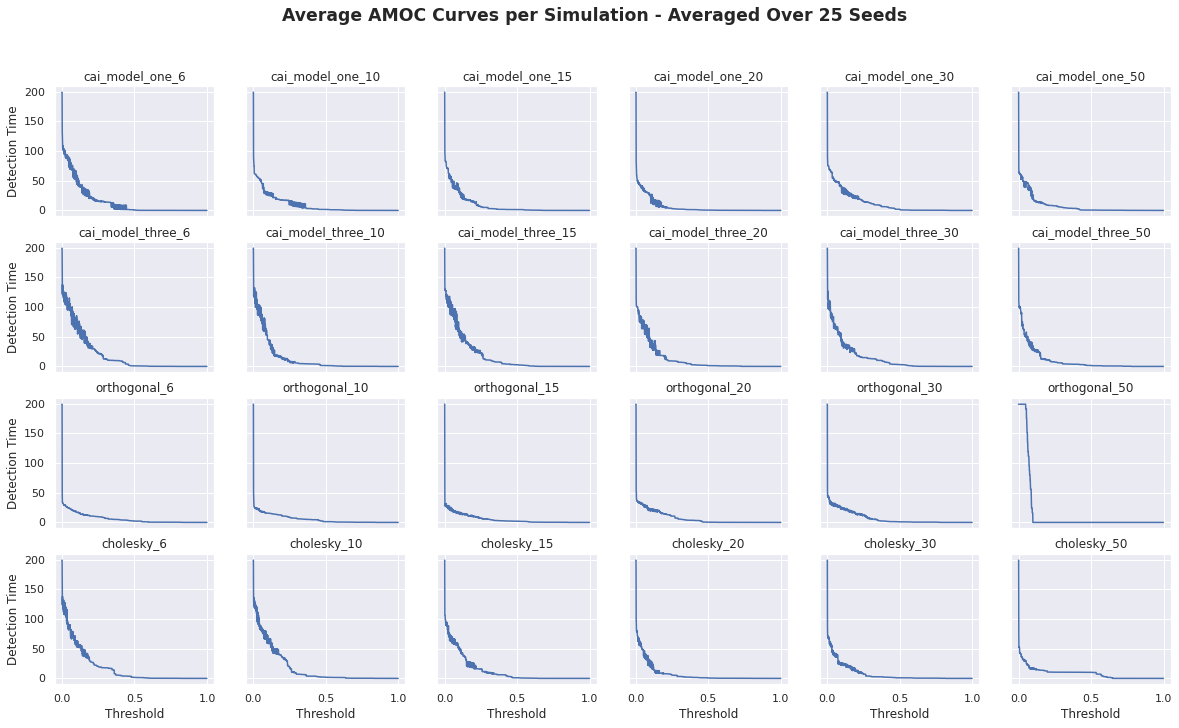

In [12]:
fig, ax = plt.subplots(4, 6, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(all_amoc_thresholds[counter], all_amoc_means[counter])
        ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='Threshold', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average AMOC Curves per Simulation - Averaged Over 25 Seeds', 
             fontsize='x-large', fontweight='semibold');

In [13]:
# shape: (sims, seeds, thresholds)
print(all_fprs.shape)
print(all_detects.shape)

(24, 25, 1000)
(24, 25, 1000)


In [14]:
mean_fprs = all_fprs.mean(axis=1)
mean_detects = all_detects.mean(axis=1)
mean_fprs.shape, mean_detects.shape

((24, 1000), (24, 1000))

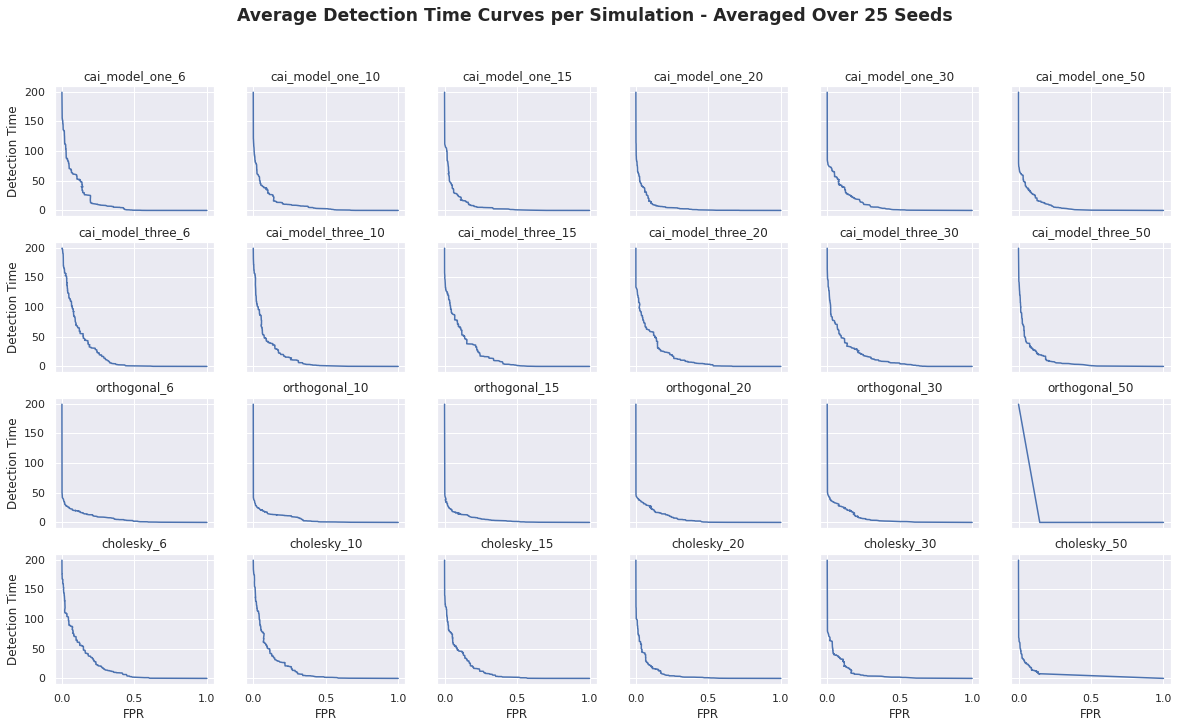

In [15]:
fig, ax = plt.subplots(4, 6, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(mean_fprs[counter], mean_detects[counter])
        ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average Detection Time Curves per Simulation - Averaged Over 25 Seeds', 
             fontsize='x-large', fontweight='semibold');

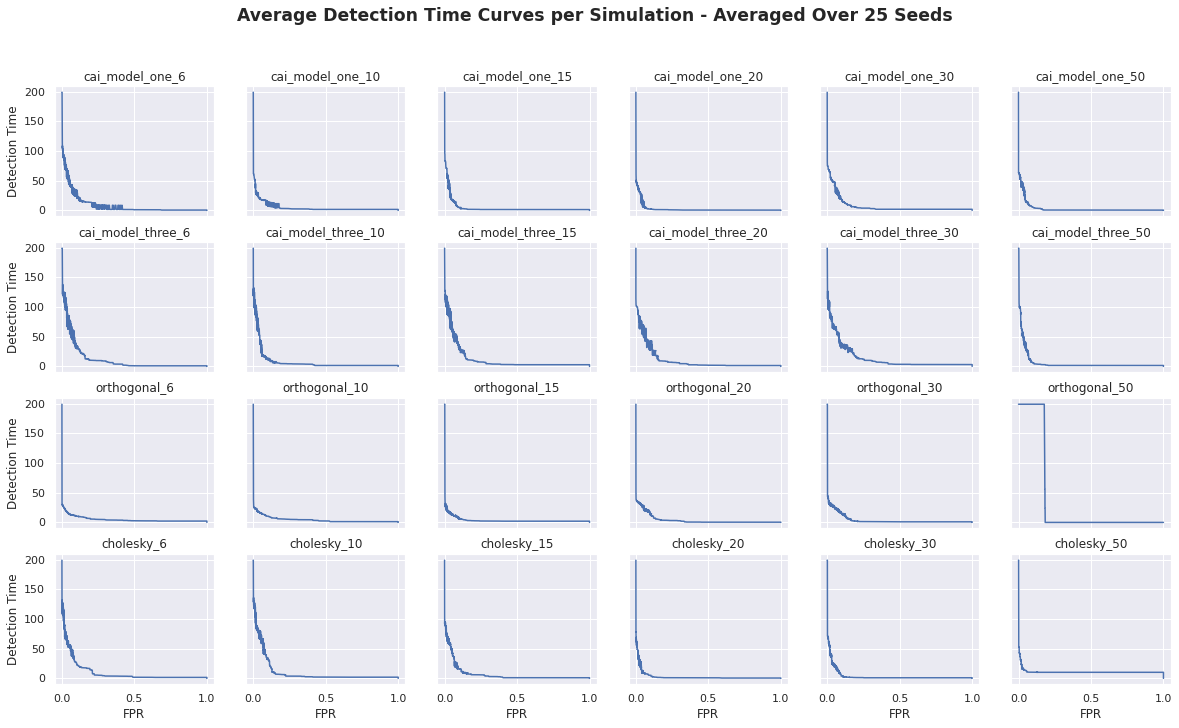

In [17]:
fig, ax = plt.subplots(4, 6, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(mean_fprs[counter], all_amoc_means[counter])
        ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average Detection Time Curves per Simulation - Averaged Over 25 Seeds', 
             fontsize='x-large', fontweight='semibold');

In [16]:
for dimstr in simulation_dims:
    print(os.listdir(os.path.join(sim_results_path, simulation_prefixes[0]+dimstr+'/55')))

['p_vals.csv', 'lrt_vals.csv', 'matrix_1.csv', 'changed_indx.csv', 'matrix_0.csv']
['p_vals.csv', 'lrt_vals.csv', 'matrix_1.csv', 'matrix_2.csv', 'changed_indx.csv', 'matrix_0.csv']
['p_vals.csv', 'lrt_vals.csv', 'matrix_3.csv', 'matrix_1.csv', 'matrix_2.csv', 'changed_indx.csv', 'matrix_0.csv']
['p_vals.csv', 'lrt_vals.csv', 'matrix_4.csv', 'matrix_5.csv', 'matrix_3.csv', 'matrix_1.csv', 'matrix_2.csv', 'changed_indx.csv', 'matrix_0.csv']
['p_vals.csv', 'lrt_vals.csv', 'matrix_4.csv', 'matrix_7.csv', 'matrix_6.csv', 'matrix_5.csv', 'matrix_3.csv', 'matrix_1.csv', 'matrix_2.csv', 'changed_indx.csv', 'matrix_0.csv']
['matrix_9.csv', 'p_vals.csv', 'lrt_vals.csv', 'matrix_4.csv', 'matrix_7.csv', 'matrix_6.csv', 'matrix_5.csv', 'matrix_10.csv', 'matrix_3.csv', 'matrix_1.csv', 'matrix_2.csv', 'matrix_8.csv', 'changed_indx.csv', 'matrix_0.csv']
